<a href="https://colab.research.google.com/github/nimraa9090/AI-projects/blob/main/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

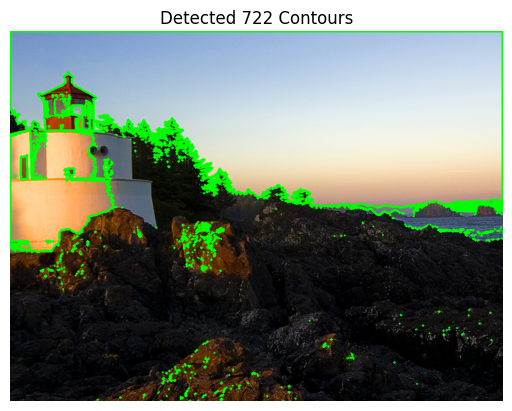

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image and convert to grayscale
img = cv2.imread("test.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply binary thresholding
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Find contours
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on the original image
img_contours = img.copy()
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 3)

plt.imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
plt.title(f"Detected {len(contours)} Contours")
plt.axis('off')
plt.show()

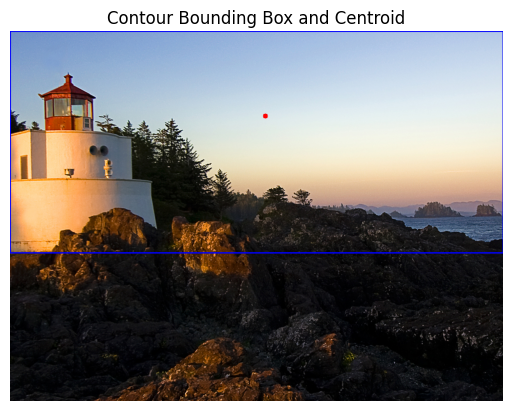

In [2]:
# Analyze the largest contour
if len(contours) > 0:
    c = max(contours, key=cv2.contourArea)

    # Bounding Rectangle
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    # Centroid (Moments)
    M = cv2.moments(c)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
        cv2.circle(img, (cX, cY), 5, (0, 0, 255), -1)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Contour Bounding Box and Centroid")
plt.axis('off')
plt.show()